In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
imo

In [ ]:
x=np.array(["Q1 Year 1", "Q2 Year 1", "Q3 Year 1", "Q4 Year 1",
            "Q1 Year 2", "Q2 Year 2", "Q3 Year 2", "Q4 Year 2",
            "Q1 Year 3", "Q2 Year 3", "Q3 Year 3", "Q4 Year 3"])

y=np.array([3,4,6,5,7,8,8,9,10,10,12,14])

In [9]:
df = pd.DataFrame({
    "Quarter": x,
    "Sale price": y
})

print(df)

      Quarter  Sale price
0   Q1 Year 1           3
1   Q2 Year 1           4
2   Q3 Year 1           6
3   Q4 Year 1           5
4   Q1 Year 2           7
5   Q2 Year 2           8
6   Q3 Year 2           8
7   Q4 Year 2           9
8   Q1 Year 3          10
9   Q2 Year 3          10
10  Q3 Year 3          12
11  Q4 Year 3          14


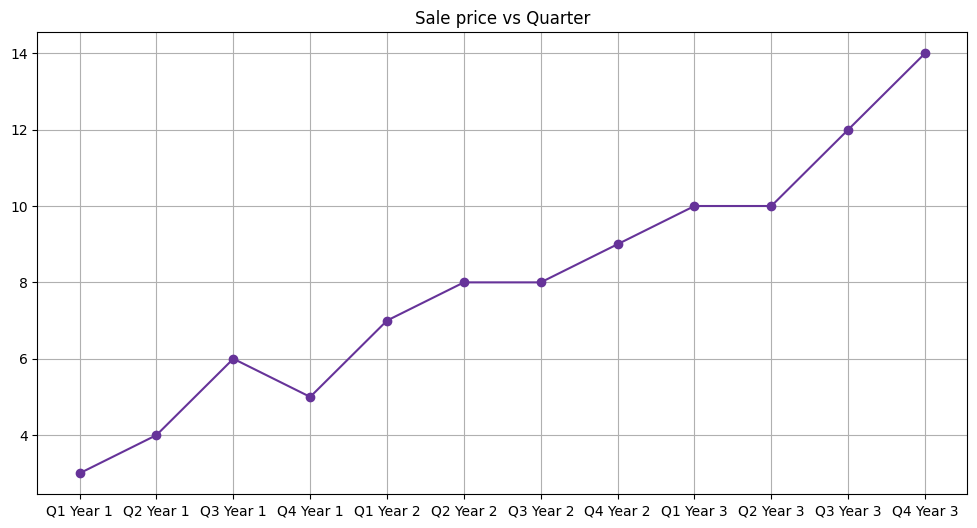

In [ ]:
plt.figure(figsize=(12, 6))  
plt.plot(x, y, marker = "o", color="rebeccapurple")
plt.title("Sale price vs Quarter")
plt.grid()
plt.show()


In [24]:
x_1=["Q1 Year 1", "Q2 Year 1", "Q3 Year 1", "Q4 Year 1",
     "Q1 Year 2", "Q2 Year 2"]
y_1= [3,4,6,5,7,8]

x_2=["Q3 Year 2", "Q4 Year 2", "Q1 Year 3", "Q2 Year 3",
     "Q3 Year 3", "Q4 Year 3"]

y_2=[8,9,10,10,12,14]

In [29]:
y1_mean= np.mean(y_1)
print("Data set 1 Sales mean: ", y1_mean)

y2_mean= np.mean(y_2)
print("Data set 2 Sales mean: ", y2_mean)

Data set 1 Sales mean:  5.5
Data set 2 Sales mean:  10.5


In [31]:
y1_variance = np.var(y_1)
print("Data set 1 Sales variance: ", y1_variance)

y2_variance = np.var(y_2)
print("Data set 1 Sales variance: ", y2_variance)

Data set 1 Sales variance:  2.9166666666666665
Data set 1 Sales variance:  3.9166666666666665


In [32]:
def naive_forecast(x):
    x_naive = [0]

    for i in range(1, len(x)):
        x_naive.append(x[i-1])

    return x_naive

In [ ]:

y_naive = naive_forecast(y)


naive_errors = all_metrics(
    np.array(y[1:]),
    np.array(y_naive[1:])
)

print("Naive Forecast Error Metrics")
for metric, value in naive_errors.items():
    print(f"{metric}: {value:.4f}")



y_naive_future = y_naive.copy()
y_naive_future.append(y[-1])  

x_extended = np.append(x, "Q1 Year 4")
y_extended = np.append(y, np.nan)

df = pd.DataFrame({
    "Quarter": x_extended,
    "Actual Sale price": y_extended,
    "Forecasted Sale price": y_naive_future,
})

print(df)

Naive Forecast Error Metrics
MAE: 1.1818
MSE: 1.9091
RMSE: 1.3817
MAPE: 15.5880
MFE: 1.0000
      Quarter  Actual Sale price  Forecasted Sale price
0   Q1 Year 1                3.0                      0
1   Q2 Year 1                4.0                      3
2   Q3 Year 1                6.0                      4
3   Q4 Year 1                5.0                      6
4   Q1 Year 2                7.0                      5
5   Q2 Year 2                8.0                      7
6   Q3 Year 2                8.0                      8
7   Q4 Year 2                9.0                      8
8   Q1 Year 3               10.0                      9
9   Q2 Year 3               10.0                     10
10  Q3 Year 3               12.0                     10
11  Q4 Year 3               14.0                     12
12  Q1 Year 4                NaN                     14


In [37]:
def moving_average_3(x):
    x_ma = [0, 0, 0]

    for i in range(3, len(x)):
        avg = (x[i-1] + x[i-2] + x[i-3]) / 3
        x_ma.append(avg)

    return x_ma

In [ ]:

y_ma = moving_average_3(y)


ma_errors = all_metrics(
    np.array(y[3:]),
    np.array(y_ma[3:])
)

print("3-Period Moving Average Error Metrics")
for metric, value in ma_errors.items():
    print(f"{metric}: {value:.4f}")



y_ma_future = y_ma.copy()


next_forecast = np.mean(y[-3:])

y_ma_future.append(next_forecast)

x_extended = np.append(x, "Q1 Year 4")
y_extended = np.append(y, np.nan)

df = pd.DataFrame({
    "Quarter": x_extended,
    "Actual Sale price": y_extended,
    "Forecasted Sale price": y_ma_future,
})

print(df)

3-Period Moving Average Error Metrics
MAE: 1.7407
MSE: 3.5926
RMSE: 1.8954
MAPE: 18.7008
MFE: 1.7407
      Quarter  Actual Sale price  Forecasted Sale price
0   Q1 Year 1                3.0               0.000000
1   Q2 Year 1                4.0               0.000000
2   Q3 Year 1                6.0               0.000000
3   Q4 Year 1                5.0               4.333333
4   Q1 Year 2                7.0               5.000000
5   Q2 Year 2                8.0               6.000000
6   Q3 Year 2                8.0               6.666667
7   Q4 Year 2                9.0               7.666667
8   Q1 Year 3               10.0               8.333333
9   Q2 Year 3               10.0               9.000000
10  Q3 Year 3               12.0               9.666667
11  Q4 Year 3               14.0              10.666667
12  Q1 Year 4                NaN              12.000000


In [ ]:
def simple_exponential_smoothing(y,alpha):
    x_ses_forecast = [0]
    forecast = y[0]  

    for i in range(1, len(y)):
        x_ses_forecast.append(forecast)
        forecast = alpha * y[i] + (1 - alpha) * forecast

    return x_ses_forecast

In [ ]:

best_alpha = None
best_mse = float('inf')

for alpha in np.arange(0.0, 1.1, 0.1):
    y_ses_temp = simple_exponential_smoothing(y, alpha)

    mse_value = mse(
        np.array(y[1:]),          
        np.array(y_ses_temp[1:])  
    )

    print(f"alpha = {alpha:.1f} | MSE = {mse_value:.4f}")

    if mse_value < best_mse:
        best_mse = mse_value
        best_alpha = alpha


print("\nBest Alpha:", round(best_alpha, 1))
print("Best MSE:", round(best_mse, 4))


y_ses = simple_exponential_smoothing(y, best_alpha)

ses_errors = all_metrics(
    np.array(y[1:]),
    np.array(y_ses[1:])
)

print("\nSimple Exponential Smoothing Error Metrics")
for metric, value in ses_errors.items():
    print(f"{metric}: {value:.4f}")


next_forecast = best_alpha * y[-1] + (1 - best_alpha) * y_ses[-1]

y_ses_future = y_ses.copy()
y_ses_future.append(next_forecast)

x_extended = np.append(x, "Q1 Year 4")
y_extended = np.append(y, np.nan)

df = pd.DataFrame({
    "Quarter": x_extended,
    "Actual Sale price": y_extended,
    "Forecasted Sale price": y_ses_future,
})

print("\nChosen Alpha:", round(best_alpha, 1))
print(df)

alpha = 0.0 | MSE = 37.8182
alpha = 0.1 | MSE = 18.7464
alpha = 0.2 | MSE = 10.5694
alpha = 0.3 | MSE = 6.7173
alpha = 0.4 | MSE = 4.7243
alpha = 0.5 | MSE = 3.6021
alpha = 0.6 | MSE = 2.9244
alpha = 0.7 | MSE = 2.4938
alpha = 0.8 | MSE = 2.2121
alpha = 0.9 | MSE = 2.0270
alpha = 1.0 | MSE = 1.9091

Best Alpha: 1.0
Best MSE: 1.9091

Simple Exponential Smoothing Error Metrics
MAE: 1.1818
MSE: 1.9091
RMSE: 1.3817
MAPE: 15.5880
MFE: 1.0000

Chosen Alpha: 1.0
      Quarter  Actual Sale price  Forecasted Sale price
0   Q1 Year 1                3.0                    0.0
1   Q2 Year 1                4.0                    3.0
2   Q3 Year 1                6.0                    4.0
3   Q4 Year 1                5.0                    6.0
4   Q1 Year 2                7.0                    5.0
5   Q2 Year 2                8.0                    7.0
6   Q3 Year 2                8.0                    8.0
7   Q4 Year 2                9.0                    8.0
8   Q1 Year 3               10.0    

In [106]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

model = SimpleExpSmoothing(y)
fit = model.fit(optimized=True)

print("Best alpha:", fit.model.params["smoothing_level"])

Best alpha: 0.9999999850988388


In [56]:
def mae_error(actual, forecast):
    return np.mean(np.abs(actual - forecast))

In [57]:
def mse_error(actual, forecast):
    return np.mean((actual - forecast)**2)

In [58]:
def rmse_error(actual, forecast):
    return np.sqrt(np.mean((actual - forecast)**2))

In [59]:
def mape_error(actual, forecast):
    return np.mean(np.abs((actual - forecast) / actual)) * 100

In [60]:
def mfe_error(actual, forecast):
    return np.mean(actual - forecast)

In [121]:
x_extended = np.append(x, "Q1 Year 4")
y_extended = np.append(y, np.nan)

In [124]:
y_naive_future = y_naive + [y[-1]]
y_ma_future = y_ma + [np.mean(y[-3:])]
y_ses_future = y_ses + [None]

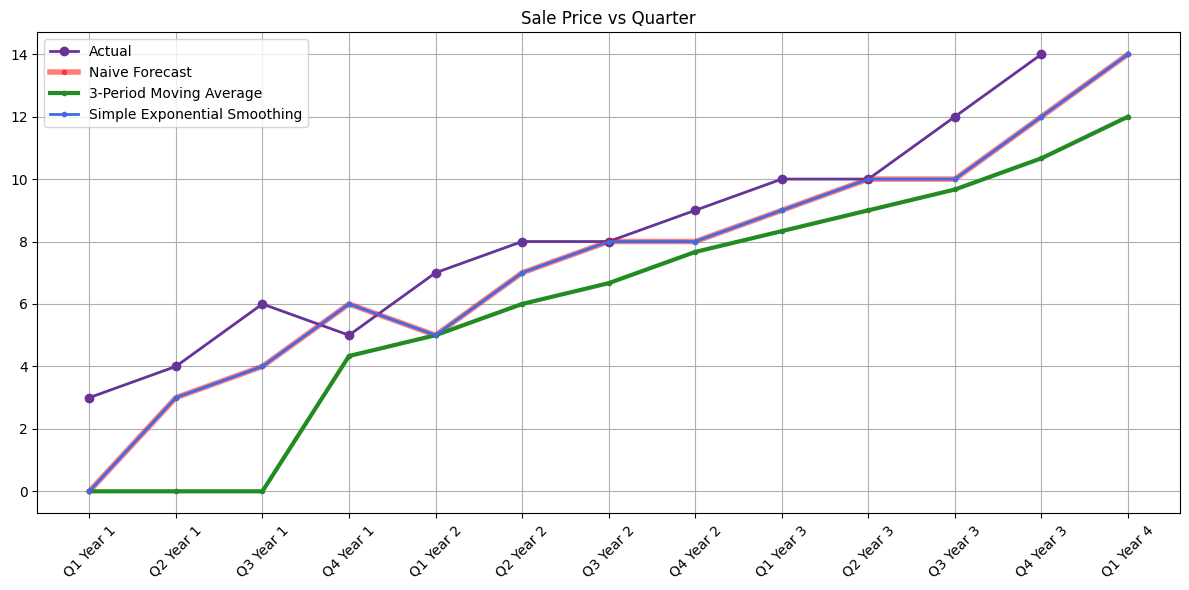

In [126]:
plt.figure(figsize=(12, 6))

plt.plot(x_extended, y_extended,
         marker="o", linewidth=2,
         color="rebeccapurple", label="Actual")

plt.plot(x_extended, y_naive_future,
         marker=".", linewidth=4, alpha=0.5,
         color="red", label="Naive Forecast")

plt.plot(x_extended, y_ma_future,
         marker=".", linewidth=3,
         color="forestgreen", label="3-Period Moving Average")

plt.plot(x_extended, y_naive_future,
         marker=".", linewidth=2,
         color="royalblue", label="Simple Exponential Smoothing")

plt.title("Sale Price vs Quarter")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [127]:
def weighted_moving_average_4(y, weights):
    y = np.array(y)
    weights = np.array(weights)

    forecasts = [0, 0, 0, 0]

    for i in range(4, len(y)):
        window = y[i-4:i]
        forecasts.append(np.dot(weights, window))

    return forecasts

In [ ]:
weights = [0.05, 0.15, 0.3, 0.5]

y_wma = weighted_moving_average_4(y, weights)

next_forecast = np.dot(weights, y[-4:])
y_wma_future = y_wma + [next_forecast]

x_extended = np.append(x, "Q1 Year 4")
y_extended = np.append(y, np.nan)

df = pd.DataFrame({
    "Quarter": x_extended,
    "Actual Sale price": y_extended,
    "Forecasted Sale price": y_wma_future
})

print(df)

wma_errors = all_metrics(y[4:], y_wma[4:])

for metric, value in wma_errors.items():
    print(f"{metric}: {value:.4f}")

      Quarter  Actual Sale price  Forecasted Sale price
0   Q1 Year 1                3.0                   0.00
1   Q2 Year 1                4.0                   0.00
2   Q3 Year 1                6.0                   0.00
3   Q4 Year 1                5.0                   0.00
4   Q1 Year 2                7.0                   5.05
5   Q2 Year 2                8.0                   6.10
6   Q3 Year 2                8.0                   7.15
7   Q4 Year 2                9.0                   7.70
8   Q1 Year 3               10.0                   8.45
9   Q2 Year 3               10.0                   9.30
10  Q3 Year 3               12.0                   9.75
11  Q4 Year 3               14.0                  10.95
12  Q1 Year 4                NaN                  12.60
MAE: 1.6938
MSE: 3.3853
RMSE: 1.8399
MAPE: 17.4640
MFE: 1.6938


In [ ]:
weights = np.array([1, 2, 3, 4]) / 10

y_wma = weighted_moving_average_4(y, weights)

next_forecast = np.dot(weights, y[-4:])
y_wma_future = y_wma + [next_forecast]

x_extended = np.append(x, "Q1 Year 4")
y_extended = np.append(y, np.nan)

df = pd.DataFrame({
    "Quarter": x_extended,
    "Actual Sale price": y_extended,
    "Forecasted Sale price": y_wma_future
})

print(df)

wma_errors = all_metrics(y[4:], y_wma[4:])

for metric, value in wma_errors.items():
    print(f"{metric}: {value:.4f}")

      Quarter  Actual Sale price  Forecasted Sale price
0   Q1 Year 1                3.0                    0.0
1   Q2 Year 1                4.0                    0.0
2   Q3 Year 1                6.0                    0.0
3   Q4 Year 1                5.0                    0.0
4   Q1 Year 2                7.0                    4.9
5   Q2 Year 2                8.0                    5.9
6   Q3 Year 2                8.0                    6.9
7   Q4 Year 2                9.0                    7.5
8   Q1 Year 3               10.0                    8.3
9   Q2 Year 3               10.0                    9.1
10  Q3 Year 3               12.0                    9.6
11  Q4 Year 3               14.0                   10.7
12  Q1 Year 4                NaN                   12.2
MAE: 1.8875
MSE: 4.0787
RMSE: 2.0196
MAPE: 19.5298
MFE: 1.8875


In [143]:

def holt_linear(y):
    y = np.array(y)
    alpha= 0.44
    beta= 0.915

    level = y[0]
    trend = y[1] - y[0]

    forecasts = [y[0]]

    for t in range(1, len(y)):
        prev_level = level

        level = alpha * y[t] + (1 - alpha) * (level + trend)
        trend = beta * (level - prev_level) + (1 - beta) * trend

        forecasts.append(level + trend)

    return forecasts

In [ ]:
best_alpha = None
best_beta = None
best_mse = float('inf')

for alpha in np.arange(0.0, 1.1, 0.001):
    for beta in np.arange(0.0, 1.1, 0.001):

        y_holt_temp = holt_linear(y, alpha, beta)

        mse_value = mse(
            np.array(y[1:]),
            np.array(y_holt_temp[1:])
        )

        if mse_value < best_mse:
            best_mse = mse_value
            best_alpha = alpha
            best_beta = beta


print("\nBest Holt Parameters")
print("Alpha:", best_alpha)
print("Beta:", best_beta)
print("Best MSE:", best_mse)


Best Holt Parameters
Alpha: 0.444
Beta: 0.915
Best MSE: 0.7950194266749684


In [135]:
from statsmodels.tsa.holtwinters import Holt

model = Holt(y)
fit = model.fit(optimized=True)

In [136]:
print("Statsmodels Alpha:", fit.model.params["smoothing_level"])
print("Statsmodels Beta:", fit.model.params["smoothing_trend"])

Statsmodels Alpha: 0.39398060708637594
Statsmodels Beta: 0.07146302432078303


In [137]:
print("\nYour Grid Search:")
print("Alpha:", best_alpha)
print("Beta:", best_beta)

print("\nStatsmodels:")
print("Alpha:", fit.model.params["smoothing_level"])
print("Beta:", fit.model.params["smoothing_trend"])


Your Grid Search:
Alpha: 0.5
Beta: 0.8

Statsmodels:
Alpha: 0.39398060708637594
Beta: 0.07146302432078303


In [ ]:
y_holt = holt_linear(y)

last_level = y_holt[-1]
last_trend = y_holt[-1] - y_holt[-2]

next_forecast = last_level + last_trend
y_holt_future = y_holt + [next_forecast]


x_extended = np.append(x, "Q1 Year 4")
y_extended = np.append(y, np.nan)


df = pd.DataFrame({
    "Quarter": x_extended,
    "Actual Sale price": y_extended,
    "Forecasted Sale price": y_holt_future
})

print(df)


holt_errors = all_metrics(
    np.array(y[1:]),
    np.array(y_holt[1:])
)

print("\nHolt Linear Error Metrics")
for metric, value in holt_errors.items():
    print(f"{metric}: {value:.4f}")

      Quarter  Actual Sale price  Forecasted Sale price
0   Q1 Year 1                3.0               3.000000
1   Q2 Year 1                4.0               5.000000
2   Q3 Year 1                6.0               6.842600
3   Q4 Year 1                5.0               6.692625
4   Q1 Year 2                7.0               7.612388
5   Q2 Year 2                8.0               8.723508
6   Q3 Year 2                8.0               9.054451
7   Q4 Year 2                9.0               9.657857
8   Q1 Year 3               10.0              10.573511
9   Q2 Year 3               10.0              10.855382
10  Q3 Year 3               12.0              12.354053
11  Q4 Year 3               14.0              14.735967
12  Q1 Year 4                NaN              17.117881

Holt Linear Error Metrics
MAE: 0.8275
MSE: 0.7951
RMSE: 0.8917
MAPE: 12.1522
MFE: -0.8275


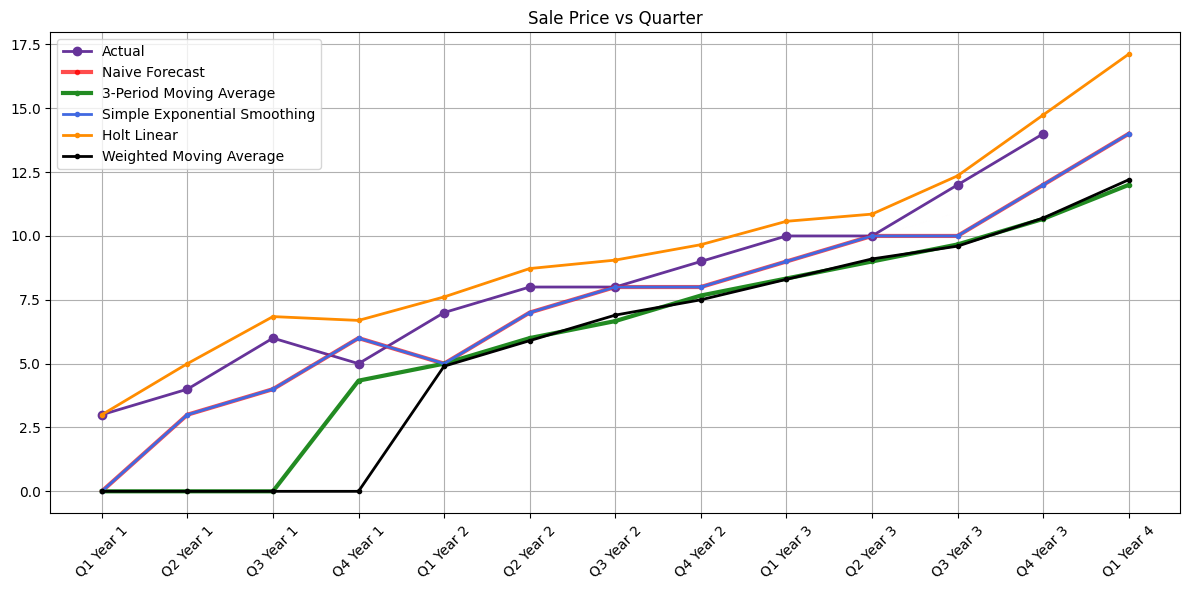

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(x_extended, y_extended,
         marker="o", linewidth=2,
         color="rebeccapurple", label="Actual")

plt.plot(x_extended, y_naive_future,
         marker=".", linewidth=3, alpha= 0.7, 
         color="red", label="Naive Forecast")


plt.plot(x_extended, y_ma_future,
         marker=".", linewidth=3,
         color="forestgreen", label="3-Period Moving Average")


plt.plot(x_extended, y_naive_future,
         marker=".", linewidth=2,
         color="royalblue", label="Simple Exponential Smoothing")


plt.plot(x_extended, y_holt_future,
         marker=".", linewidth=2,
         color="darkorange", label="Holt Linear")


plt.plot(x_extended, y_wma_future,
         marker=".", linewidth=2,
         color="black", label="Weighted Moving Average")


plt.title("Sale Price vs Quarter")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()